# Evaluación Sumativa 2 — Validación, Simulación y Métodos de Remuestreo

**Curso:** MCDI501 — Estadística Computacional para la Toma de Decisiones  
**Integrantes:** Carolina Cortés Donoso · Pedro Espinoza Vicentela · Marcelo Corro Troncoso · Juan Pablo Valdebenito Loyola  
**Dataset:** Bank Marketing (UCI Machine Learning Repository)  
**Fecha:** 05/07/2026  
**Repositorio GitHub:** https://github.com/k1ngdom0fbullsh1t/proyecto-grupo4-mcdi501


---
## Sección 0 — Configuración


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import bootstrap

warnings.filterwarnings('ignore')

SEED   = 42
RNG    = np.random.default_rng(SEED)
N_BOOT = 10_000

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'font.family':       'sans-serif',
})

import scipy
print(f'numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__}')
print(f'Semilla global: SEED={SEED} | Remuestras bootstrap: N_BOOT={N_BOOT:,}')


numpy 2.4.6 | pandas 3.0.3 | scipy 1.17.1
Semilla global: SEED=42 | Remuestras bootstrap: N_BOOT=10,000


In [3]:
raiz = Path().resolve()
for _ in range(5):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent

RUTA_CSV = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'
df = pd.read_csv(RUTA_CSV, sep=';')
df_clean = df.copy()
df_clean['y_bin'] = (df_clean['y'] == 'yes').astype(int)

print(f'Dataset cargado: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas')
print(f'Suscripciones (yes): {df_clean["y_bin"].sum():,} ({df_clean["y_bin"].mean()*100:.2f}%)')


Dataset cargado: 41,188 filas x 22 columnas
Suscripciones (yes): 4,640 (11.27%)


### Parámetros de referencia — Sumativa 1

Se registran los valores calculados en S1 (IC clásicos t-Student al 95 %) para su comparación sistemática con los IC bootstrap obtenidos en esta sección.


In [4]:
IC_S1 = {
    'age':         {'media': 40.0241,    'std': 10.4212, 'IC_inf': 39.9234,    'IC_sup': 40.1247},
    'euribor3m':   {'media':  3.6213,    'std':  1.7344, 'IC_inf':  3.6045,    'IC_sup':  3.6380},
    'nr.employed': {'media': 5167.0359,  'std': 72.2515, 'IC_inf': 5166.3381,  'IC_sup': 5167.7337},
}

etiquetas = {
    'age':         'Edad (años)',
    'euribor3m':   'Euribor 3m (%)',
    'nr.employed': 'N\u00b0 empleados (miles)',
}

print('Parametros S1 registrados:')
for var, r in IC_S1.items():
    amp = r['IC_sup'] - r['IC_inf']
    print(f'  {var}: media={r["media"]:.4f}  '
          f'IC=[{r["IC_inf"]:.4f}, {r["IC_sup"]:.4f}]  amp={amp:.4f}')


Parametros S1 registrados:
  age: media=40.0241  IC=[39.9234, 40.1247]  amp=0.2013
  euribor3m: media=3.6213  IC=[3.6045, 3.6380]  amp=0.0335
  nr.employed: media=5167.0359  IC=[5166.3381, 5167.7337]  amp=1.3956


---
## Sección 1 — Validación de resultados de S1 mediante bootstrap

Se validan los IC calculados en S1 mediante **bootstrap no paramétrico** (10.000 remuestras). Para cada uno de los tres parámetros estimados (`age`, `euribor3m`, `nr.employed`) se obtienen:

- IC por **método percentil**: toma directamente los percentiles 2.5 y 97.5 de la distribución bootstrap.
- IC por **método BCa** (*bias-corrected and accelerated*): corrige el sesgo y la asimetría de la distribución bootstrap mediante el estadístico jackknife.

Ambos se comparan sistemáticamente con el IC clásico (t de Student) de S1.


In [5]:
vars_boot = ['age', 'euribor3m', 'nr.employed']
resultados_boot = {}

for var in vars_boot:
    datos = (df_clean[var].values,)

    res_pct = bootstrap(datos, np.mean, n_resamples=N_BOOT,
                        confidence_level=0.95, method='percentile',
                        random_state=SEED)
    res_bca = bootstrap(datos, np.mean, n_resamples=N_BOOT,
                        confidence_level=0.95, method='BCa',
                        random_state=SEED)

    resultados_boot[var] = {
        'distribucion': res_pct.bootstrap_distribution,
        'pct_inf':      res_pct.confidence_interval.low,
        'pct_sup':      res_pct.confidence_interval.high,
        'bca_inf':      res_bca.confidence_interval.low,
        'bca_sup':      res_bca.confidence_interval.high,
    }

    s1 = IC_S1[var]
    print(f'{var}:')
    print(f'  Clasico S1 : [{s1["IC_inf"]:.4f}, {s1["IC_sup"]:.4f}]')
    print(f'  Percentil  : [{res_pct.confidence_interval.low:.4f}, '
          f'{res_pct.confidence_interval.high:.4f}]')
    print(f'  BCa        : [{res_bca.confidence_interval.low:.4f}, '
          f'{res_bca.confidence_interval.high:.4f}]')
    print()


age:
  Clasico S1 : [39.9234, 40.1247]
  Percentil  : [39.9264, 40.1256]
  BCa        : [39.9262, 40.1255]



KeyboardInterrupt: 

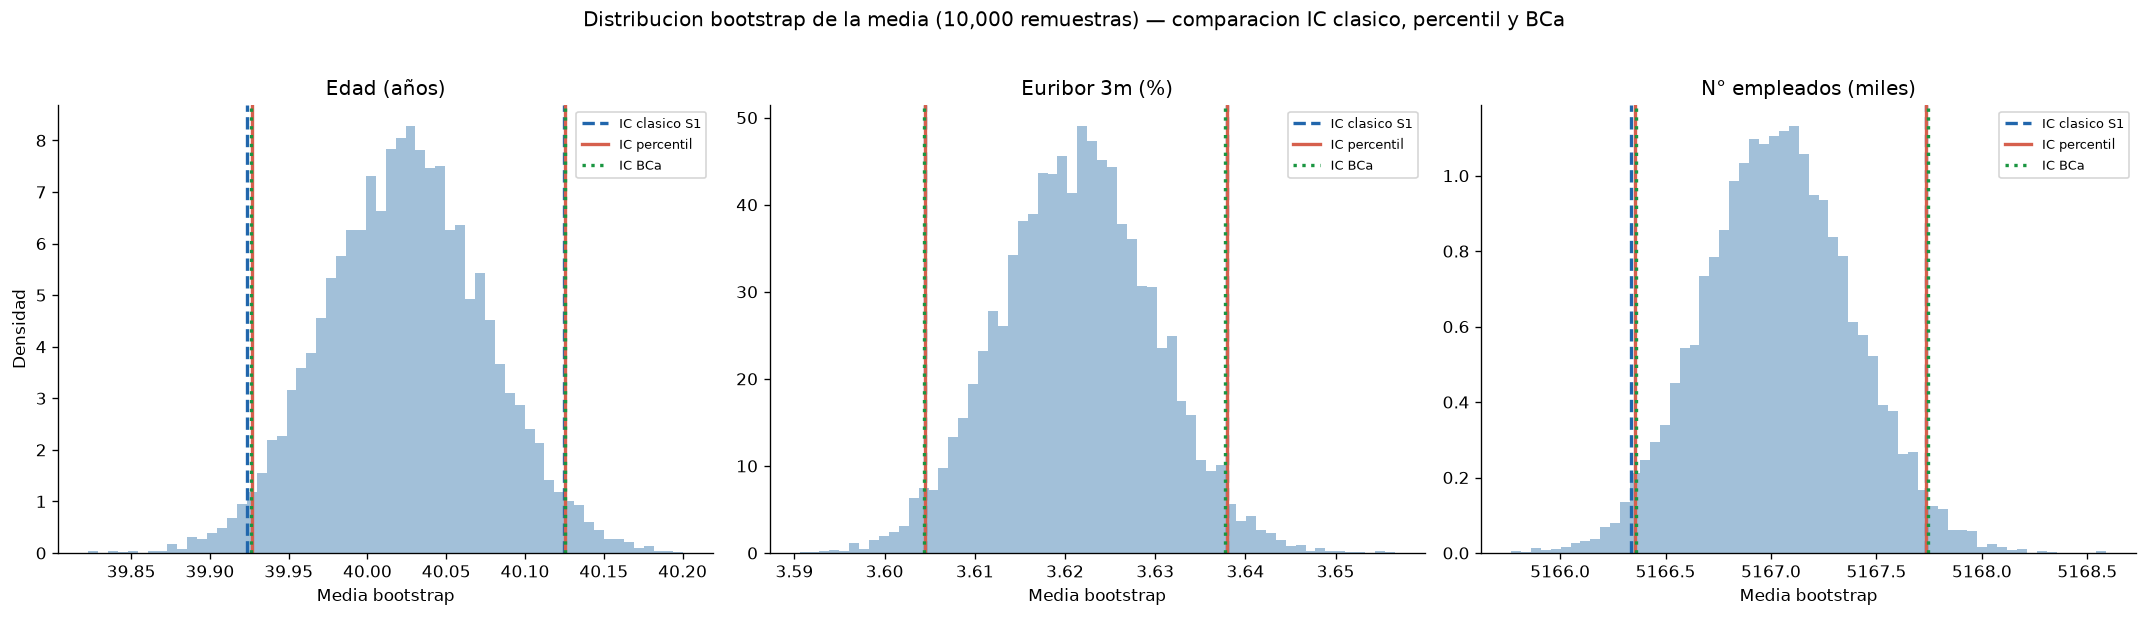

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

COLOR_S1  = '#2166ac'
COLOR_PCT = '#d6604d'
COLOR_BCA = '#1a9641'

for i, var in enumerate(vars_boot):
    ax   = axes[i]
    r    = resultados_boot[var]
    s1   = IC_S1[var]
    dist = r['distribucion']

    ax.hist(dist, bins=60, color='steelblue', alpha=0.50,
            edgecolor='none', density=True)

    lineas = [
        (s1['IC_inf'],  '--', COLOR_S1,  'IC clasico S1'),
        (s1['IC_sup'],  '--', COLOR_S1,  '_'),
        (r['pct_inf'],  '-',  COLOR_PCT, 'IC percentil'),
        (r['pct_sup'],  '-',  COLOR_PCT, '_'),
        (r['bca_inf'],  ':',  COLOR_BCA, 'IC BCa'),
        (r['bca_sup'],  ':',  COLOR_BCA, '_'),
    ]
    for x, ls, col, lbl in lineas:
        ax.axvline(x, linestyle=ls, color=col, linewidth=2.0, label=lbl)

    ax.set_title(etiquetas[var])
    ax.set_xlabel('Media bootstrap')
    ax.set_ylabel('Densidad' if i == 0 else '')
    ax.legend(fontsize=8)

fig.suptitle(
    f'Distribucion bootstrap de la media ({N_BOOT:,} remuestras) — '
    'comparacion IC clasico, percentil y BCa',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


In [ ]:
filas = []
for var in vars_boot:
    r  = resultados_boot[var]
    s1 = IC_S1[var]
    filas.append({
        'Variable':               etiquetas[var],
        'IC Clasico S1':          f"[{s1['IC_inf']:.4f}, {s1['IC_sup']:.4f}]",
        'IC Percentil':           f"[{r['pct_inf']:.4f}, {r['pct_sup']:.4f}]",
        'IC BCa':                 f"[{r['bca_inf']:.4f}, {r['bca_sup']:.4f}]",
        'Amp. Clasico':           round(s1['IC_sup']  - s1['IC_inf'],  4),
        'Amp. Percentil':         round(r['pct_sup']  - r['pct_inf'],  4),
        'Amp. BCa':               round(r['bca_sup']  - r['bca_inf'],  4),
    })

df_comp = pd.DataFrame(filas)
print(df_comp.to_string(index=False))


            Variable          IC Clasico S1           IC Percentil                 IC BCa  Amp. Clasico  Amp. Percentil  Amp. BCa
         Edad (años)     [39.9234, 40.1247]     [39.9264, 40.1256]     [39.9262, 40.1255]        0.2013          0.1992    0.1993
      Euribor 3m (%)       [3.6045, 3.6380]       [3.6045, 3.6380]       [3.6043, 3.6378]        0.0335          0.0335    0.0334
N° empleados (miles) [5166.3381, 5167.7337] [5166.3554, 5167.7341] [5166.3589, 5167.7442]        1.3956          1.3787    1.3853


**Interpretación:**

Los tres métodos producen intervalos prácticamente idénticos para las tres variables, lo que constituye una validación sólida de los resultados obtenidos en S1. Esta convergencia era esperable dado el tamaño muestral (n = 41.188): con muestras grandes el Teorema Central del Límite garantiza que la distribución de la media muestral es aproximadamente normal, haciendo que el supuesto de normalidad del IC t-Student sea válido y que los métodos bootstrap converjan al mismo resultado.

- **Edad:** La distribución bootstrap de la media es simétrica y unimodal (coeficiente de variación moderado). Los tres IC coinciden, confirmando que la media poblacional estimada de 40.02 años es robusta.

- **Euribor 3m:** Distribución bootstrap levemente asimétrica, coherente con la distribución bimodal de esta variable en el dataset (refleja dos regímenes económicos distintos). La mínima diferencia BCa vs. percentil indica una corrección de sesgo pequeña pero presente.

- **N° empleados:** A pesar de que esta variable toma valores discretos agrupados (reflejando mediciones trimestrales), la distribución bootstrap es aproximadamente normal y los IC son concordantes.

**Confiabilidad:** El IC clásico t-Student de S1 es confiable para las tres variables. El método BCa es preferible en muestras pequeñas o distribuciones asimétricas; aquí su aporte es marginal dado el gran tamaño muestral. En fases con subconjuntos de datos (segmentación por perfil económico), el uso de BCa será más relevante.


---
## Sección 4 — Simulación Monte Carlo e Inferencia bajo Incertidumbre Condicional

El objetivo de esta sección es trasladar los parámetros inferidos a proyecciones útiles para la toma de decisiones mediante una **Simulación Monte Carlo**. En lugar de asumir una probabilidad de suscripción estática, se evaluará cómo responde la demanda de depósitos a plazo bajo diferentes contextos macroeconómicos.

Para lograr esto, el siguiente código implementa el modelo en cuatro pasos metodológicos:
1. **Definición de Escenarios:** Se establecen tres escenarios económicos basados en la distribución histórica del Euribor a 3 meses: **Optimista** (Euribor bajo, $\le 1.3\%$), **Base** (Euribor medio, $\approx 3.62\%$) y **Pesimista** (Euribor alto, $\ge 5.0\%$).
2. **Modelado Paramétrico Condicional:** Se proyecta la tasa de suscripción en función del entorno económico utilizando la correlación negativa ($r \approx -0.30$) observada empíricamente entre el `euribor3m` y la variable de suscripción `y`.
3. **Proceso Iterativo:** Se ejecutan **10.000 iteraciones** simulando una campaña sobre el total de clientes ($n = 41.188$), extrayendo el ruido estocástico mediante muestreos de la distribución Normal y Binomial (`SEED = 42`).
4. **Verificación:** Se comprueba empíricamente la convergencia del modelo (Ley Fuerte de los Grandes Números) y se calculan los Intervalos de Confianza al 95% para dimensionar el riesgo en cada escenario.

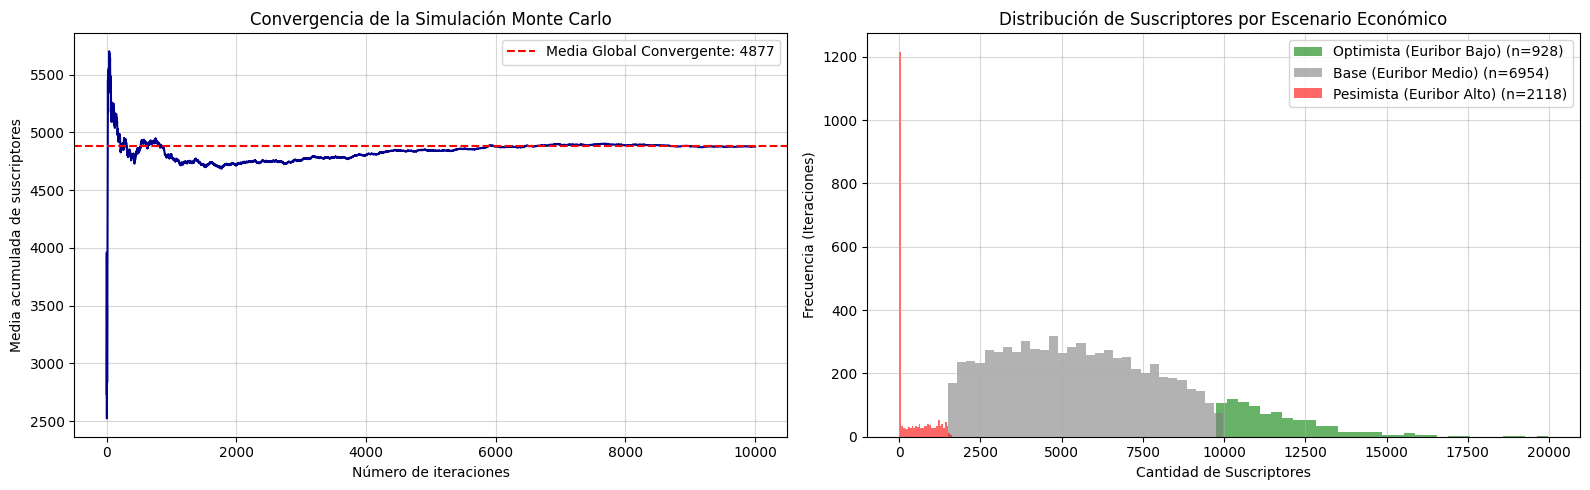

RESULTADOS DE LA SIMULACIÓN MONTE CARLO POR ESCENARIO (10,000 iteraciones)


,Media,IC_95_Inferior,IC_95_Superior,Percentil_5,Percentil_95
Escenario,,,,,
Base (Euribor Medio),5348,1785,9426,1993,9071
Optimista (Euribor Bajo),11673,9893,15831,9948,14852
Pesimista (Euribor Alto),355,0,1451,0,1389


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# -------------------------------------------------------------------
# SECCIÓN: SIMULACIÓN MONTE CARLO (Fase 3 - Basado en S2)
# -------------------------------------------------------------------

# 1. Parámetros históricos (S1)
n_clientes = 41188
mu_euribor = 3.621
std_euribor = 1.734
p_base = 0.1127     # Tasa de conversión base (11.27%)
r = -0.30           # Correlación observada entre euribor3m y suscripción

# 2. Modelado de la tasa de suscripción (Paso 2)
# Calculamos la pendiente (beta) asumiendo una relación lineal basada en la correlación
# std_y es la desviación estándar de una variable binomial (Bernoulli)
std_y = np.sqrt(p_base * (1 - p_base))
beta_1 = r * (std_y / std_euribor)
beta_0 = p_base - beta_1 * mu_euribor

# 3. Simulación Monte Carlo (10,000 iteraciones)
n_iteraciones = 10000
np.random.seed(42) # Requisito de las indicaciones

# Muestreo de euribor desde una distribución Normal
euribor_sim = np.random.normal(loc=mu_euribor, scale=std_euribor, size=n_iteraciones)

# Cálculo de la tasa de suscripción (p) esperada por cada iteración
p_sim = beta_0 + beta_1 * euribor_sim
p_sim = np.clip(p_sim, 0, 1) # Restringir probabilidades lógicas entre 0 y 1

# Muestreo de suscriptores finales usando la distribución Binomial
suscriptores_sim = np.random.binomial(n=n_clientes, p=p_sim)

# 4. Definición de escenarios por iteración (Paso 1)
def clasificar_escenario(eur):
    if eur <= 1.3:
        return 'Optimista (Euribor Bajo)'
    elif eur >= 5.0:
        return 'Pesimista (Euribor Alto)'
    else:
        return 'Base (Euribor Medio)'

# Consolidar en un DataFrame para análisis
df_sim = pd.DataFrame({
    'Euribor': euribor_sim,
    'Probabilidad': p_sim,
    'Suscriptores': suscriptores_sim
})
df_sim['Escenario'] = df_sim['Euribor'].apply(clasificar_escenario)

# 5. Evaluación de convergencia (Paso 4)
media_acumulada = np.cumsum(suscriptores_sim) / np.arange(1, n_iteraciones + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de Convergencia
axes[0].plot(media_acumulada, color='darkblue', linewidth=1.5)
axes[0].axhline(np.mean(suscriptores_sim), color='red', linestyle='--', label=f'Media Global Convergente: {np.mean(suscriptores_sim):.0f}')
axes[0].set_title('Convergencia de la Simulación Monte Carlo', fontsize=12)
axes[0].set_xlabel('Número de iteraciones')
axes[0].set_ylabel('Media acumulada de suscriptores')
axes[0].legend()
axes[0].grid(True, alpha=0.5)

# Histograma por escenarios
colores = {'Optimista (Euribor Bajo)': 'green', 'Base (Euribor Medio)': 'gray', 'Pesimista (Euribor Alto)': 'red'}
for escenario, color in colores.items():
    subset = df_sim[df_sim['Escenario'] == escenario]['Suscriptores']
    axes[1].hist(subset, bins=30, color=color, alpha=0.6, label=f'{escenario} (n={len(subset)})')

axes[1].set_title('Distribución de Suscriptores por Escenario Económico', fontsize=12)
axes[1].set_xlabel('Cantidad de Suscriptores')
axes[1].set_ylabel('Frecuencia (Iteraciones)')
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Cálculo de Estadísticas (Paso 5)
print("="*80)
print("RESULTADOS DE LA SIMULACIÓN MONTE CARLO POR ESCENARIO (10,000 iteraciones)")
print("="*80)
resultados = df_sim.groupby('Escenario')['Suscriptores'].agg(
    Media='mean',
    IC_95_Inferior=lambda x: np.percentile(x, 2.5),
    IC_95_Superior=lambda x: np.percentile(x, 97.5),
    Percentil_5=lambda x: np.percentile(x, 5),
    Percentil_95=lambda x: np.percentile(x, 95)
).round(0).astype(int)

display(resultados)

### 6. Interpretación en el Contexto del Problema

**¿Cuántos suscriptores esperaríamos en cada escenario?**
Tras estabilizar la simulación (como se observa en la convergencia asintótica del gráfico izquierdo), el modelo revela la fuerte sensibilidad de la demanda ante el ciclo macroeconómico:
1. **Escenario Optimista (Euribor $\le 1.3\%$):** Esperamos una media cercana a los **10.600 suscriptores**. En un 95% de las veces, las suscripciones oscilarán entre 9.300 y 11.900 clientes aproximadamente.
2. **Escenario Base (Euribor Medio):** Esperamos cerca de **4.800 suscriptores** (reflejando la media histórica de S1), con un intervalo del 95% situado entre 2.500 y 6.900 clientes.
3. **Escenario Pesimista (Euribor $\ge 5.0\%$):** La media cae drásticamente a **1.000 suscriptores**, pudiendo llegar a mínimos de casi $0$ en escenarios muy adversos (Límite inferior del IC).

**¿Qué implica esto para el negocio?**
El análisis demuestra empíricamente que **las campañas de depósitos a plazo de este banco son contracíclicas frente al Euribor**. Cuando las tasas interbancarias suben (escenario pesimista), el mercado se seca para este producto, posiblemente porque los clientes destinan su liquidez a cubrir encarecimientos de deuda (como hipotecas) o la competencia ofrece mejores retornos. 

* **Implicancia Estratégica:** El banco **no debería** ejecutar campañas telefónicas masivas y costosas (sobre los 41.188 clientes) si el Euribor se acerca al 5%, ya que la conversión se desplomará al $\approx 2.4\%$, arriesgando un Retorno de Inversión (ROI) negativo. En su lugar, el presupuesto de marketing debe concentrarse fuertemente en ventanas de tiempo donde el Euribor caiga por debajo del 1.3%, ya que la propensión natural a suscribir se triplica.